# 10 — Facility-Level Downturn LGD

## Estimating the loss after default

PD is complete. This notebook estimates how much of EAD would be lost after recoveries and costs, with a separate downturn view for each facility.

For own-estimate facilities, downturn LGD enters expected loss and the IRB unexpected-loss capital function after floors. Lower collateral recovery, longer workouts and higher costs increase LGD and usually increase IRB RWA.

### Recovery and loss language

| Term | Simple meaning |
|---|---|
| Economic loss | EAD minus discounted recoveries plus material workout costs |
| Normal LGD | loss severity under ordinary recovery assumptions |
| Downturn LGD | loss severity reflecting periods of high credit losses where relevant |
| Workout cost | legal, servicing and recovery expense associated with default |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


> Recovery rates, recovery times and workout costs are synthetic. A bank would estimate LGD from discounted recoveries and costs on defaulted facilities, form a long-run default-weighted average and reflect periods of high loss severity.

## Recovery-to-LGD calculation

For each facility, collateral and unsecured recoveries are estimated, discounted over the recovery period and reduced for workout cost. Downturn assumptions lower recovery rates, increase costs and extend recovery time. Downturn LGD cannot fall below normal LGD in this implementation.

In [2]:
lgd_example = loans.loc[loans["collateral_value"].gt(0)].iloc[0]
display(pd.Series({
    "Product": lgd_example["product_type"],
    "EAD (INR crore)": lgd_example["ead_irb"] / CRORE,
    "Collateral value (INR crore)": lgd_example["collateral_value"] / CRORE,
    "Normal discounted recovery (INR crore)": lgd_example["normal_discounted_recovery"] / CRORE,
    "Normal workout cost (INR crore)": lgd_example["normal_workout_cost"] / CRORE,
    "Normal LGD": lgd_example["normal_lgd"],
    "Downturn discounted recovery (INR crore)": lgd_example["downturn_discounted_recovery"] / CRORE,
    "Downturn workout cost (INR crore)": lgd_example["downturn_workout_cost"] / CRORE,
    "Downturn LGD": lgd_example["downturn_lgd"],
}).to_frame("Value"))

,Value
Product,mortgage
EAD (INR crore),0.209763
Collateral value (INR crore),0.287241
Normal discounted recovery (INR crore),0.186893
Normal workout cost (INR crore),0.006293
Normal LGD,0.139027
Downturn discounted recovery (INR crore),0.170859
Downturn workout cost (INR crore),0.012586
Downturn LGD,0.245467


The difference between normal and downturn LGD is not a universal fixed add-on. It comes from the facility's collateral, unsecured recovery, cost and timing assumptions. The recovery assumptions are synthetic; they are not fitted to observed defaults.

## Normal and downturn LGD by product

The chart shows EAD-weighted average LGD. Secured products can have lower normal LGD, but downturn collateral and recovery assumptions narrow that benefit.

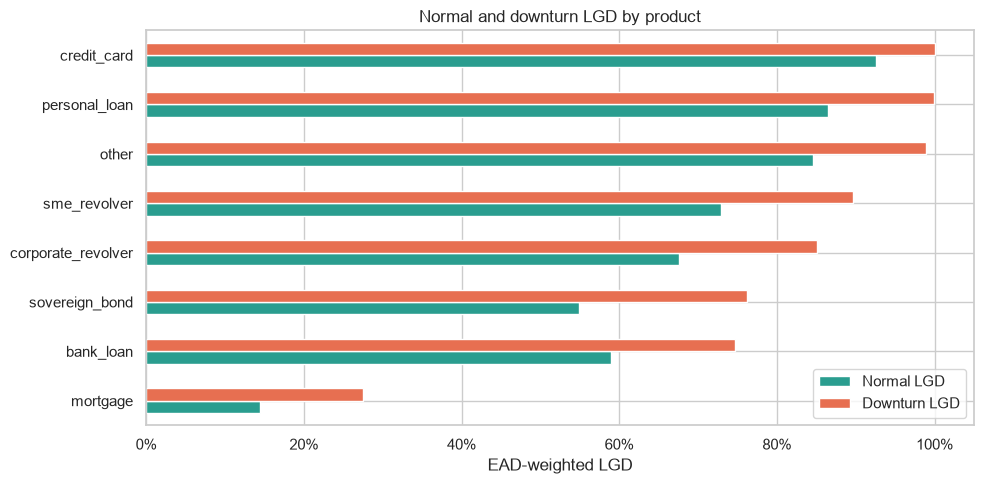

In [3]:
lgd_by_product = loans.groupby("product_type").apply(
    lambda group: pd.Series({
        "Normal LGD": np.average(group["normal_lgd"], weights=group["ead_irb"]),
        "Downturn LGD": np.average(group["downturn_lgd"], weights=group["ead_irb"]),
    }),
    include_groups=False,
).sort_values("Downturn LGD")
lgd_by_product.plot.barh(figsize=(10, 5), color=[COLORS[2], COLORS[5]], title="Normal and downturn LGD by product")
plt.xlabel("EAD-weighted LGD")
plt.ylabel("")
plt.gca().xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.tight_layout()
plt.show()

The gap between each pair of bars is the downturn effect. A higher downturn LGD means a larger share of EAD is assumed to remain unrecovered during difficult conditions and therefore increases both expected and unexpected loss measures.

## From recovery estimates to the LGD used for capital

For synthetic recoveries, unsecured recovery applies to the balance remaining after collateral proceeds. Both loss and recovery use IRB EAD. Own estimates then face exposure-specific floors: 5% for mortgages, 50% for QRRE, 30% for unsecured other retail and 25% for unsecured corporates. Secured floors depend on collateral; sovereign LGD has no floor here.

Foundation LGD is calculated separately: 45% for unsecured banks and 40% for unsecured other corporates. Eligible cash has a 0% secured LGD; eligible property has 20%, with a 40% property haircut. For example, EAD of INR 1 crore and property worth INR 0.5 crore give recognised collateral of INR 0.3 crore and corporate LGD of 0.3 × 20% + 0.7 × 40% = 34%. Eligibility of the synthetic collateral is assumed. The same-currency, senior-claim example omits currency and maturity mismatches.

In [4]:
lgd_routes = loans.groupby(["irb_parameter_source", "irb_function", "collateral_type"]).agg(loans=("exposure_id", "count"), average_recovery_lgd=("downturn_lgd", "mean"), average_final_lgd=("lgd_regulatory", "mean"), minimum_floor=("lgd_floor_applied", "min"))
display(lgd_routes.style.format({"average_recovery_lgd": "{:.1%}", "average_final_lgd": "{:.1%}", "minimum_floor": "{:.1%}"}))